In [9]:
#Inspired by https://avandekleut.github.io/vae/
import torch;
import torch.nn as nn
import torch.utils
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [11]:
class FF(nn.Module):
    def __init__(self,dim1,dim2,dim3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_features=dim1, out_features=dim2),
            nn.ReLU(),
            nn.Linear(in_features=dim2, out_features=dim3)
        )

    def forward(self, input):
        return self.main(input)
tmp = FF(28*28,512,2)
print(tmp)
print(tmp(torch.rand(10,1,28*28)).shape)

FF(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=2, bias=True)
  )
)
torch.Size([10, 1, 2])


In [12]:
class Autoencoder(nn.Module):
    def __init__(self, dim1, dim2, dim3):
        super().__init__()
        self.encoder = FF(dim1, dim2, dim3)
        self.decoder = nn.Sequential(
            FF(dim3, dim2, dim1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
tmp = Autoencoder(28*28,512,2)
print(tmp)
print(tmp(torch.rand(10,1,28*28)).shape)

Autoencoder(
  (encoder): FF(
    (main): Sequential(
      (0): Linear(in_features=784, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=2, bias=True)
    )
  )
  (decoder): Sequential(
    (0): FF(
      (main): Sequential(
        (0): Linear(in_features=2, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=784, bias=True)
      )
    )
    (1): Sigmoid()
  )
)
torch.Size([10, 1, 784])


In [13]:
def train(data_loader, model, optimizer, loss_function, epochs=20):
    model.to(device) # GPU
    losses = []
    for epoch in range(epochs):
        for i, (x, y) in enumerate(data_loader):
            x = x.to(device) # GPU
            optimizer.zero_grad()
            x_hat = model(x)
            loss = loss_function(x, x_hat)
            losses.append(loss.clone().detach().cpu().numpy())
            loss.backward()
            optimizer.step()
            if i % 100 == 0:
                print(f"{epoch}/{i}: {loss}")
    return (model, losses)

In [14]:
def plot_latent(data_loader, encoder, dim1=0, dim2=1, num_batches=100):
    for i, (x, y) in enumerate(data_loader):
        z = encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0, dim1], z[:, 0, dim2], c=y, alpha=0.5)
        if i > num_batches:
            plt.colorbar()
            break

In [24]:
def plot_reconstructed(decoder, w, h, r0=(-10, 10), r1=(-10, 10), n=12):
    img = np.zeros((n*w, n*h))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).view(1,1,2).to(device)
            x_hat = decoder(z)
            x_hat = x_hat.reshape(w, h).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    #plt.figure(figsize=(20,20))
    plt.imshow(img, extent=[*r0, *r1])

In [16]:
# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x,start_dim=-2))
])

data = datasets.MNIST('./data',transform=transform,download=True)

n, w, h = data.data.shape

data_loader = torch.utils.data.DataLoader(data,batch_size=128,shuffle=True)

model = Autoencoder(w*h, 512, 2)

optimizer = torch.optim.Adam(model.parameters())

loss_function = torch.nn.MSELoss()

(autoencoder, losses) = train(data_loader, model, optimizer, loss_function,20)

0/0: 0.23293019831180573
0/100: 0.05869691073894501
0/200: 0.052360571920871735
0/300: 0.05030588060617447
0/400: 0.0488792285323143
1/0: 0.050670333206653595
1/100: 0.048533324152231216
1/200: 0.04992383345961571
1/300: 0.04638764634728432
1/400: 0.05002879723906517
2/0: 0.04685452580451965
2/100: 0.04562654718756676
2/200: 0.04878945276141167
2/300: 0.045594025403261185
2/400: 0.0447065494954586
3/0: 0.04563862085342407
3/100: 0.04482177644968033
3/200: 0.0459471121430397
3/300: 0.04723464325070381
3/400: 0.042970433831214905
4/0: 0.04540389031171799
4/100: 0.04354657977819443
4/200: 0.04345521330833435
4/300: 0.04434231296181679
4/400: 0.04639579728245735
5/0: 0.04553540050983429
5/100: 0.04237477108836174
5/200: 0.04524289444088936
5/300: 0.04314139857888222
5/400: 0.04349854588508606
6/0: 0.04387351870536804
6/100: 0.04699977487325668
6/200: 0.043400492519140244
6/300: 0.042334042489528656
6/400: 0.04376843199133873
7/0: 0.04149860143661499
7/100: 0.04454006999731064
7/200: 0.0454

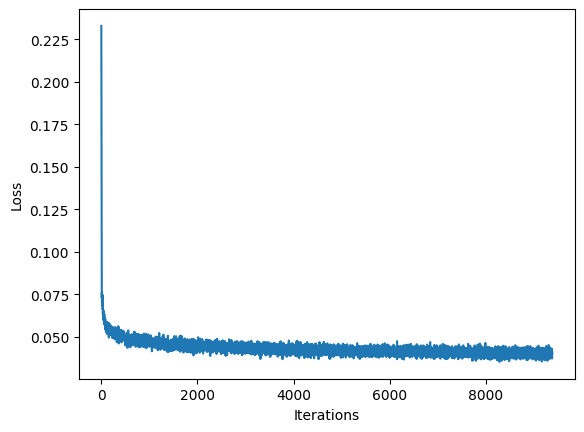

In [17]:
# Defining the Plot Style
plt.xlabel('Iterations')
plt.ylabel('Loss')

# Plotting the losses
plt.plot(losses)

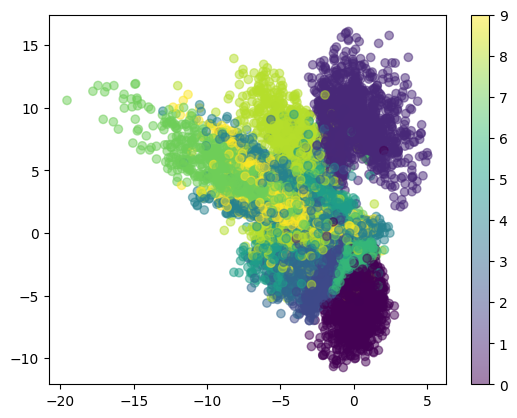

In [18]:
# Plot latent space
plot_latent(data_loader, autoencoder.encoder)
#plt.savefig('latent.pdf')

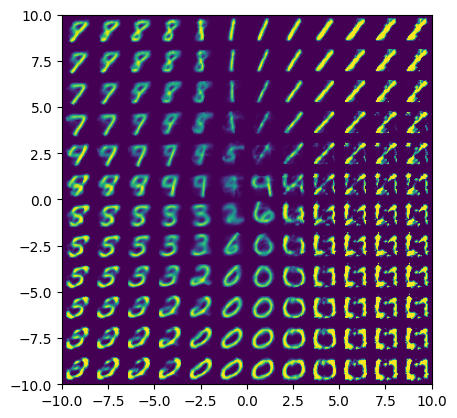

In [25]:
# Generate samples from latent space
plot_reconstructed(autoencoder.decoder,w,h)
#plt.savefig('reconstruction.pdf')

# 2.2

60000 28 28
mse: 0.05595270317336724
r2: 0.06970776766993761
np.min(X_rec): -0.6150038310220338
np.mean(X_rec): -4.7743955123502903e-14
np.max(X_rec): 1.2347322595375854


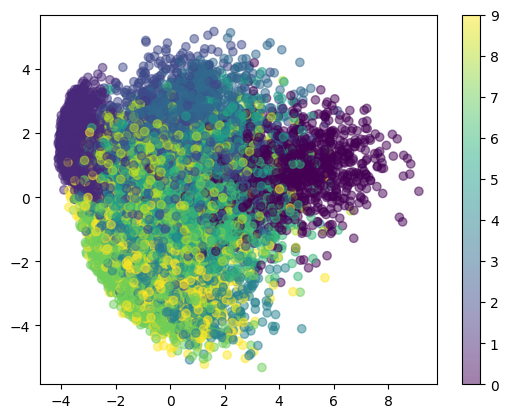

C:\Users\Martin\AppData\Local\Temp\ipykernel_18172\3101572467.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat


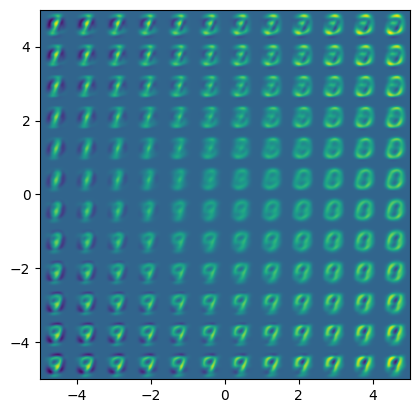

Is PCA repeatable? No


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
from torchvision import datasets, transforms
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error, r2_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def plot_latent_pca(X, Y, dim1=0, dim2=1, Num=100*128):
    plt.scatter(X[:Num, dim1], X[:Num, dim2], c=Y[:Num], alpha=0.5)#, cmap='tab10')
    plt.colorbar()
    plt.show() 

def plot_reconstructed_pca(decoder, w, h, r0=(0, 4), r1=(0, 4), n=12):
    img = np.zeros((n*w, n*h))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).view(1,1,2).to(device)
            x_hat = decoder(z)
            x_hat = x_hat.reshape(w, h)
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])
    plt.show()

# Load MNIST Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x, start_dim=-2))
])
data = datasets.MNIST('./data', transform=transform, download=True)

n, w, h = data.data.shape
print(n, w, h)

X = data.data.reshape(n, w * h).numpy()
Y = data.targets.numpy()
X, Y = shuffle(X, Y)
   
X_scaled = X / 255.0 # Normalize to [0, 1]
X_scaled = X_scaled - np.mean(X_scaled) # Zero mean   
# X_scaled = (X * 2 / 255.0) - 1 # Normalize to [-1, 1]
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_rec = pca.inverse_transform(X_pca)

# Error
mse = mean_squared_error(X_scaled, X_rec)
r2 = r2_score(X_scaled, X_rec)
print(f"mse: {mse}")
print(f"r2: {r2}") 
print(f"np.min(X_rec): {np.min(X_rec)}") 
print(f"np.mean(X_rec): {np.mean(X_rec)}") 
print(f"np.max(X_rec): {np.max(X_rec)}")

plot_latent_pca(X_pca, Y)          
plot_reconstructed_pca(pca.inverse_transform,w,h, r0=(-5, 5), r1=(-5, 5))

# Verify Repeatability
pca1 = PCA(n_components=2, random_state=1, svd_solver='randomized')
pca2 = PCA(n_components=2, random_state=2, svd_solver='randomized')
X_pca1 = pca1.fit_transform(X_scaled)
X_pca2 = pca2.fit_transform(X_scaled)
repeatable = np.allclose(X_pca1, X_pca2)
print(f"Is PCA repeatable? {'Yes' if repeatable else 'No'}")

# 2.3

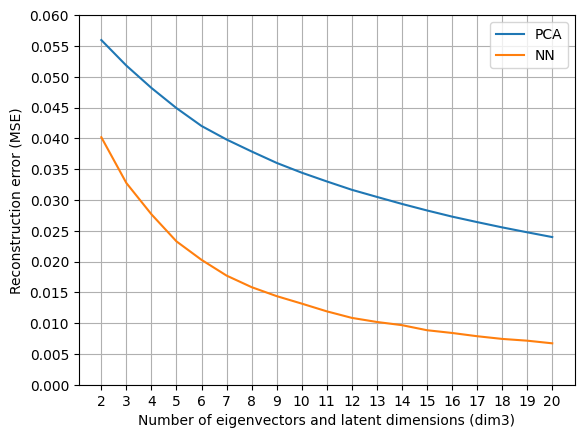

In [ ]:
# Plot reconstruction error versus number of latent nodes
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torchvision import datasets, transforms
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

# Load MNIST Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x, start_dim=-2))
])
data = datasets.MNIST('./data', transform=transform, download=True)

n, w, h = data.data.shape

X = data.data.reshape(n, w * h).numpy()
Y = data.targets.numpy()
X, Y = shuffle(X, Y)
   
X_scaled = X / 255.0 # Normalize to [0, 1]
X_scaled = X_scaled - np.mean(X_scaled) # Zero mean   

data_loader = torch.utils.data.DataLoader(data,batch_size=128,shuffle=True)
loss_function = torch.nn.MSELoss()
# full data for final model error
full_data = torch.utils.data.DataLoader(data,batch_size=n)
for i, (x, y) in enumerate(full_data):
    full_data = x

pca_loss = []
nn_loss = []
dim3 = np.arange(2, 20+1, step=1)

for c in dim3:
    print(f"dim3 = {c}")
    # Apply PCA
    pca = PCA(n_components=c)
    X_pca = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_pca)
    pca_loss.append(mean_squared_error(X_scaled, X_rec))

    # Train NN
    model = Autoencoder(w*h, 512, c)
    optimizer = torch.optim.Adam(model.parameters())
    (autoencoder, _) = train(data_loader, model, optimizer, loss_function,20)
    x_hat = autoencoder(full_data)
    l = loss_function(full_data, x_hat)
    nn_loss.append(l.clone().detach().cpu().numpy())

plt.plot(dim3, pca_loss, label='PCA')
plt.plot(dim3, nn_loss, label='NN')
plt.xticks(dim3)
plt.yticks(np.arange(0, 0.065, step=0.005))
plt.grid()
plt.legend()
plt.xlabel('Number of eigenvectors and latent dimensions (dim3)')
plt.ylabel('Reconstruction error (MSE)')
plt.show()